# 01 — Exploratory Data Analysis

**Dataset:** IEEE-CIS Fraud Detection (Kaggle).  
**Goal of this notebook:** understand the data well enough to make informed choices in preprocessing (step 3) and training (step 4).

Sections:
1. Setup and configuration
2. Load and merge transaction + identity tables
3. Memory footprint and dtype optimization
4. Schema overview and column families
5. Target distribution (class imbalance)
6. Missingness analysis
7. `TransactionAmt` — distribution and fraud separation
8. Temporal patterns (`TransactionDT`)
9. Key categorical features (`ProductCD`, `card4`, `card6`, email domains)
10. Identity-table coverage
11. Top numeric correlations with `isFraud`
12. Notes for feature engineering (step 3)

## 1. Setup

Paths are read from `.env` (or fall back to `data/raw/...`). Logging replaces `print` for anything that should survive into a script later.

In [1]:
import logging
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv

load_dotenv()

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    force=True,
)
log = logging.getLogger("eda")

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid", context="notebook")

REPO_ROOT = Path.cwd().parent
TXN_CSV = REPO_ROOT / os.getenv("TRAIN_TRANSACTION_CSV", "data/raw/train_transaction.csv")
ID_CSV = REPO_ROOT / os.getenv("TRAIN_IDENTITY_CSV", "data/raw/train_identity.csv")

log.info("Repo root: %s", REPO_ROOT)
log.info("Transaction CSV: %s", TXN_CSV)
log.info("Identity CSV:    %s", ID_CSV)
assert TXN_CSV.exists(), f"Missing {TXN_CSV}"
assert ID_CSV.exists(), f"Missing {ID_CSV}"

2026-05-23 20:09:04,024 | INFO | Repo root: /Users/apple/Desktop/fraud_det
2026-05-23 20:09:04,025 | INFO | Transaction CSV: /Users/apple/Desktop/fraud_det/data/raw/train_transaction.csv
2026-05-23 20:09:04,026 | INFO | Identity CSV:    /Users/apple/Desktop/fraud_det/data/raw/train_identity.csv


## 2. Load and merge

`train_identity` is a *sparse* table — only a subset of transactions have an identity record. We `LEFT JOIN` on `TransactionID` so every transaction is kept and identity columns are `NaN` when absent.

In [2]:
def reduce_memory(df: pd.DataFrame) -> pd.DataFrame:
    """Downcast numeric columns to the smallest dtype that holds them.

    Reading large CSVs into pandas defaults to int64/float64, which is wasteful
    for this dataset (many columns fit in int8/float32). Roughly halves memory
    use without changing values.
    """
    start_mb = df.memory_usage(deep=True).sum() / 1024**2
    for col in df.select_dtypes(include=["integer"]).columns:
        df[col] = pd.to_numeric(df[col], downcast="integer")
    for col in df.select_dtypes(include=["float"]).columns:
        df[col] = pd.to_numeric(df[col], downcast="float")
    end_mb = df.memory_usage(deep=True).sum() / 1024**2
    log.info("Memory: %.0f MB -> %.0f MB (%.0f%% saved)", start_mb, end_mb, 100 * (1 - end_mb / start_mb))
    return df

log.info("Reading transaction CSV...")
transaction = reduce_memory(pd.read_csv(TXN_CSV))
log.info("Reading identity CSV...")
identity = reduce_memory(pd.read_csv(ID_CSV))

log.info("transaction shape: %s", transaction.shape)
log.info("identity shape:    %s", identity.shape)

2026-05-23 20:09:58,652 | INFO | Reading transaction CSV...
2026-05-23 20:10:35,883 | INFO | Memory: 2101 MB -> 1242 MB (41% saved)
2026-05-23 20:10:35,888 | INFO | Reading identity CSV...
2026-05-23 20:10:37,300 | INFO | Memory: 158 MB -> 144 MB (8% saved)
2026-05-23 20:10:37,301 | INFO | transaction shape: (590540, 394)
2026-05-23 20:10:37,302 | INFO | identity shape:    (144233, 41)


In [3]:
df = transaction.merge(identity, on="TransactionID", how="left")
log.info("merged shape:  %s", df.shape)
log.info("merged memory: %.0f MB", df.memory_usage(deep=True).sum() / 1024**2)
df.head()

2026-05-23 20:11:03,249 | INFO | merged shape:  (590540, 434)
2026-05-23 20:11:05,970 | INFO | merged memory: 1656 MB


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,...,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,debit,330.0,87.0,287.0,NaN,outlook.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,debit,476.0,87.0,NaN,NaN,yahoo.com,NaN,2.0,5.0,0.0,0.0,0.0,4.0,0.0,0.0,1.0,0.0,1.0,0.0,25.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,credit,420.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,...,100.0,NotFound,NaN,-480.0,New,NotFound,166.0,NaN,542.0,144.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,Android 7.0,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


## 4. Schema and column families

The dataset has ~430 columns, but they fall into clear families. Grouping them up front makes the rest of the analysis tractable.

| Family | Columns | Meaning |
|---|---|---|
| core | `TransactionID`, `isFraud`, `TransactionDT`, `TransactionAmt`, `ProductCD` | identifiers + headline features |
| `card1`–`card6` | payment card metadata | |
| `addr1`, `addr2` | billing address codes | |
| `dist1`, `dist2` | (anonymized) distances | |
| `P_emaildomain`, `R_emaildomain` | purchaser / recipient email | |
| `C1`–`C14` | counting features | |
| `D1`–`D15` | timedelta features | |
| `M1`–`M9` | match flags (T/F) | |
| `V1`–`V339` | engineered/anonymized features by Vesta | |
| `id_*`, `Device*` | identity-table fields | |

In [4]:
def matches_prefix_then_digits(col: str, prefix: str) -> bool:
    """Return True for names like 'V123' but not 'V_dummy' — anchors family detection."""
    return col.startswith(prefix) and col[len(prefix):].isdigit()

core_cols = ["TransactionID", "isFraud", "TransactionDT", "TransactionAmt", "ProductCD"]
column_families: dict[str, list[str]] = {
    "core":     [c for c in core_cols if c in df.columns],
    "card":     [c for c in df.columns if c.startswith("card")],
    "addr":     [c for c in df.columns if c.startswith("addr")],
    "dist":     [c for c in df.columns if c.startswith("dist")],
    "email":    [c for c in df.columns if "emaildomain" in c],
    "C":        [c for c in df.columns if matches_prefix_then_digits(c, "C")],
    "D":        [c for c in df.columns if matches_prefix_then_digits(c, "D")],
    "M":        [c for c in df.columns if matches_prefix_then_digits(c, "M")],
    "V":        [c for c in df.columns if matches_prefix_then_digits(c, "V")],
    "identity": [c for c in df.columns if c.startswith(("id_", "Device"))],
}

covered = {c for cols in column_families.values() for c in cols}
uncovered = sorted(set(df.columns) - covered)
log.info("Columns covered by families: %d / %d", len(covered), df.shape[1])
if uncovered:
    log.info("Uncovered (first 10): %s", uncovered[:10])

pd.DataFrame({"n_cols": {k: len(v) for k, v in column_families.items()}})

2026-05-23 20:12:07,648 | INFO | Columns covered by families: 434 / 434


,n_cols
core,5
card,6
addr,2
dist,2
email,2
C,14
D,15
M,9
V,339
identity,40


## 5. Target distribution

We expect ~3.5% fraud. Confirm before anything else — this drives the choice of SMOTE in step 3 and our evaluation metrics in step 5 (we will lean on ROC-AUC + precision/recall, not accuracy).

          count  percent
isFraud                 
0        569877   96.501
1         20663    3.499


2026-05-23 20:12:37,201 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-05-23 20:12:37,218 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


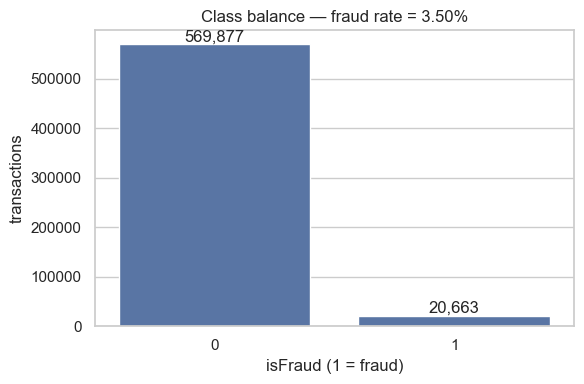

In [5]:
target_counts = df["isFraud"].value_counts().sort_index()
target_pct = (df["isFraud"].value_counts(normalize=True).sort_index() * 100).round(3)
summary = pd.DataFrame({"count": target_counts, "percent": target_pct})
print(summary)

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x=target_counts.index, y=target_counts.values, ax=ax)
ax.set(
    xlabel="isFraud (1 = fraud)",
    ylabel="transactions",
    title=f"Class balance — fraud rate = {target_pct[1]:.2f}%",
)
for i, v in enumerate(target_counts.values):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom")
plt.tight_layout()
plt.show()

## 6. Missingness

Many columns in this dataset are >90% null (especially the `V*` block). Strategy for step 3:
* Drop columns above some threshold (e.g. > 95%) unless they're predictive on the non-null subset.
* For the rest, impute (median for numeric, `"missing"` token for categorical) and add `_was_missing` flags for high-signal columns.

In [6]:
missing_pct = df.isna().mean() * 100

family_missing = pd.DataFrame({
    family: missing_pct[cols].describe()[["mean", "min", "50%", "max"]]
    for family, cols in column_families.items()
    if cols
}).T.round(1)
family_missing.columns = ["mean_missing_%", "min_%", "median_%", "max_%"]
family_missing.sort_values("mean_missing_%", ascending=False)

,mean_missing_%,min_%,median_%,max_%
identity,84.5,75.6,79.2,99.2
dist,76.6,59.7,76.6,93.6
D,58.2,0.2,52.5,93.4
M,49.9,28.7,47.7,59.3
email,46.4,16.0,46.4,76.8
V,43.0,0.0,47.3,86.1
addr,11.1,11.1,11.1,11.1
card,0.5,0.0,0.3,1.5
core,0.0,0.0,0.0,0.0
C,0.0,0.0,0.0,0.0


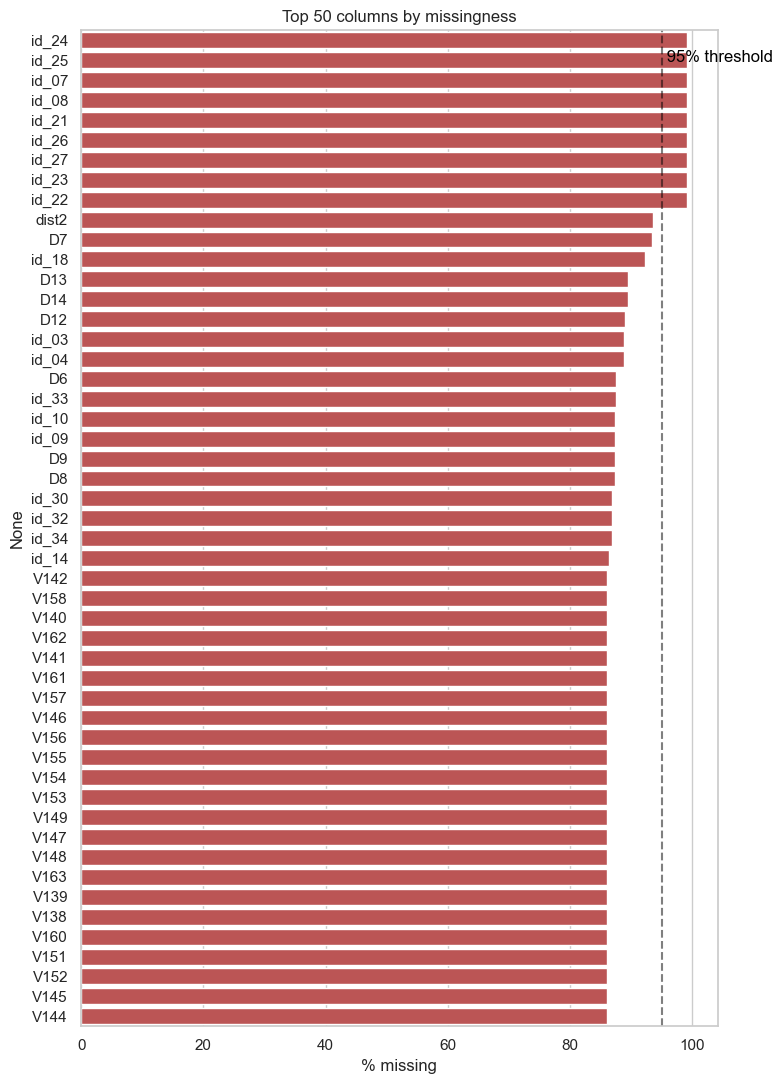

2026-05-23 20:13:01,512 | INFO | Columns > 95% missing: 9
2026-05-23 20:13:01,518 | INFO | Columns > 50% missing: 214


In [7]:
top_missing = missing_pct.sort_values(ascending=False).head(50)
fig, ax = plt.subplots(figsize=(8, 11))
sns.barplot(x=top_missing.values, y=top_missing.index, ax=ax, color="#cc4444")
ax.set(xlabel="% missing", title="Top 50 columns by missingness")
ax.axvline(95, ls="--", color="black", alpha=0.5)
ax.text(95, 0.5, " 95% threshold", color="black", va="top")
plt.tight_layout()
plt.show()

n_above_95 = (missing_pct > 95).sum()
n_above_50 = (missing_pct > 50).sum()
log.info("Columns > 95%% missing: %d", n_above_95)
log.info("Columns > 50%% missing: %d", n_above_50)

## 7. `TransactionAmt`

Headline numeric feature. Heavily right-skewed — almost certainly needs a `log1p` transform before linear models. (XGBoost is tree-based so it's invariant to monotonic transforms, but the log helps visualization and pairs well with downstream feature engineering.)

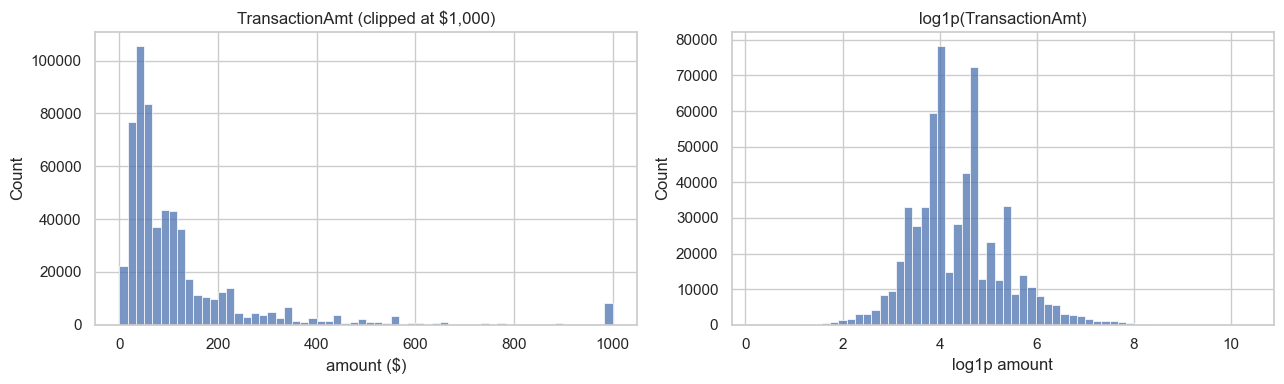

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,569877.0,134.51,239.40,0.25,43.97,68.5,120.0,31937.39
1,20663.0,149.24,232.21,0.29,35.04,75.0,161.0,5191.00


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(df["TransactionAmt"].clip(upper=1000), bins=60, ax=axes[0])
axes[0].set(title="TransactionAmt (clipped at $1,000)", xlabel="amount ($)")
sns.histplot(np.log1p(df["TransactionAmt"]), bins=60, ax=axes[1])
axes[1].set(title="log1p(TransactionAmt)", xlabel="log1p amount")
plt.tight_layout()
plt.show()

df.groupby("isFraud")["TransactionAmt"].describe().round(2)

## 8. Temporal patterns

`TransactionDT` is *seconds elapsed from an unspecified reference*, not a real timestamp. We can still derive useful cyclical features: hour-of-day and day-index. Fraud rate often spikes at night.

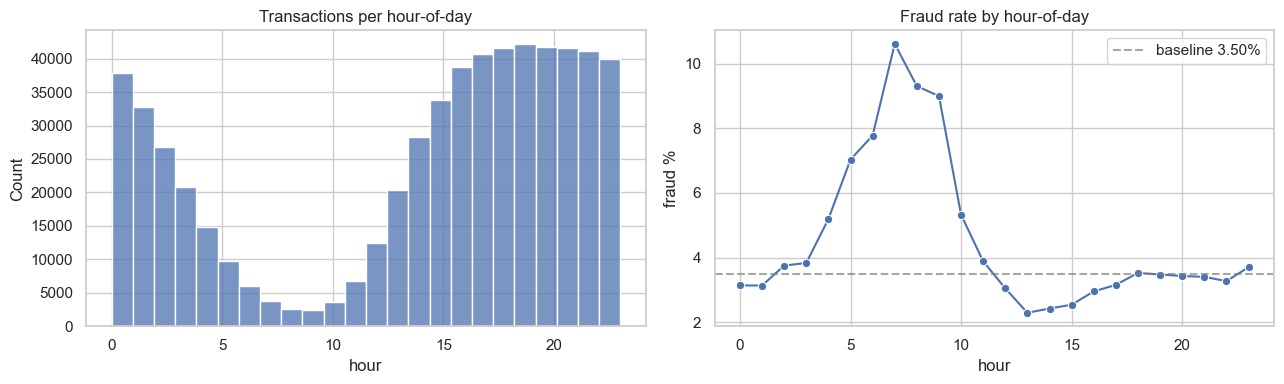

2026-05-23 20:13:21,214 | INFO | Day range covered: 182 days


In [9]:
hour_of_day = (df["TransactionDT"] / 3600 % 24).astype(int)
day_index = (df["TransactionDT"] // (24 * 3600)).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(hour_of_day, bins=24, ax=axes[0])
axes[0].set(title="Transactions per hour-of-day", xlabel="hour")

fraud_rate_by_hour = df.assign(hour=hour_of_day).groupby("hour")["isFraud"].mean() * 100
sns.lineplot(x=fraud_rate_by_hour.index, y=fraud_rate_by_hour.values, ax=axes[1], marker="o")
axes[1].axhline(target_pct[1], ls="--", color="grey", alpha=0.7, label=f"baseline {target_pct[1]:.2f}%")
axes[1].set(title="Fraud rate by hour-of-day", xlabel="hour", ylabel="fraud %")
axes[1].legend()
plt.tight_layout()
plt.show()

log.info("Day range covered: %d days", day_index.nunique())

## 9. Key categorical features

Fraud rate broken down by `ProductCD`, `card4` (card network: visa/mc/...), `card6` (debit/credit), and top email domains.

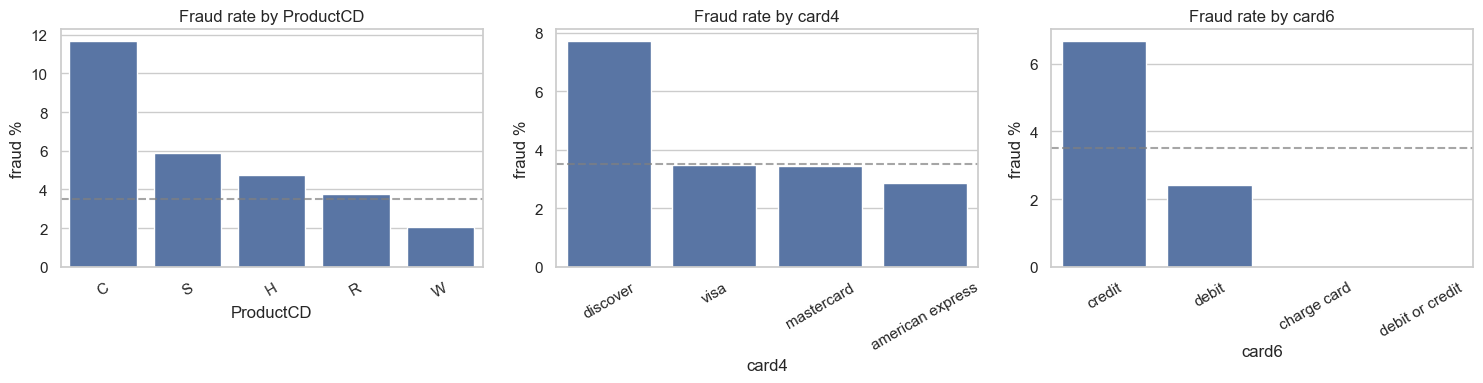

In [10]:
cat_cols = ["ProductCD", "card4", "card6"]
fig, axes = plt.subplots(1, len(cat_cols), figsize=(15, 4))
for ax, col in zip(axes, cat_cols):
    rate = (
        df.groupby(col)["isFraud"]
          .agg(fraud_rate="mean", n="size")
          .assign(fraud_pct=lambda r: r["fraud_rate"] * 100)
          .sort_values("fraud_pct", ascending=False)
    )
    sns.barplot(x=rate.index.astype(str), y=rate["fraud_pct"], ax=ax)
    ax.axhline(target_pct[1], ls="--", color="grey", alpha=0.7)
    ax.set(title=f"Fraud rate by {col}", ylabel="fraud %", xlabel=col)
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

In [11]:
top_emails = df["P_emaildomain"].value_counts().head(15).index
email_summary = (
    df[df["P_emaildomain"].isin(top_emails)]
      .groupby("P_emaildomain")["isFraud"]
      .agg(fraud_rate="mean", n="size")
      .assign(fraud_pct=lambda r: (r["fraud_rate"] * 100).round(2))
      .sort_values("fraud_pct", ascending=False)
)
email_summary

,fraud_rate,n,fraud_pct
P_emaildomain,,,
outlook.com,0.094584,5096,9.46
hotmail.com,0.052950,45250,5.30
gmail.com,0.043542,228355,4.35
icloud.com,0.031434,6267,3.14
comcast.net,0.031187,7888,3.12
bellsouth.net,0.027763,1909,2.78
live.com,0.027622,3041,2.76
anonymous.com,0.023217,36998,2.32
yahoo.com,0.022757,100934,2.28


## 10. Identity-table coverage

The identity table only attaches to a subset of transactions. Knowing the coverage rate informs whether identity features can be used directly (they'll be ~80% NaN for the full set) or only inside a model that handles missingness natively (XGBoost does).

In [12]:
has_identity = df["DeviceType"].notna()
log.info("Transactions with identity record: %.1f%%", has_identity.mean() * 100)

if has_identity.any():
    print("\nDeviceType vs fraud rate:")
    print(
        df.groupby("DeviceType")["isFraud"]
          .agg(fraud_rate="mean", n="size")
          .assign(fraud_pct=lambda r: (r["fraud_rate"] * 100).round(2))
    )

2026-05-23 20:13:51,745 | INFO | Transactions with identity record: 23.8%



DeviceType vs fraud rate:
            fraud_rate      n  fraud_pct
DeviceType                              
desktop       0.065215  85165       6.52
mobile        0.101662  55645      10.17


## 11. Top numeric correlations with `isFraud`

Pearson correlations are crude (they miss nonlinear and interaction effects that XGBoost will pick up), but they're a quick way to spot columns worth keeping in the V-block.

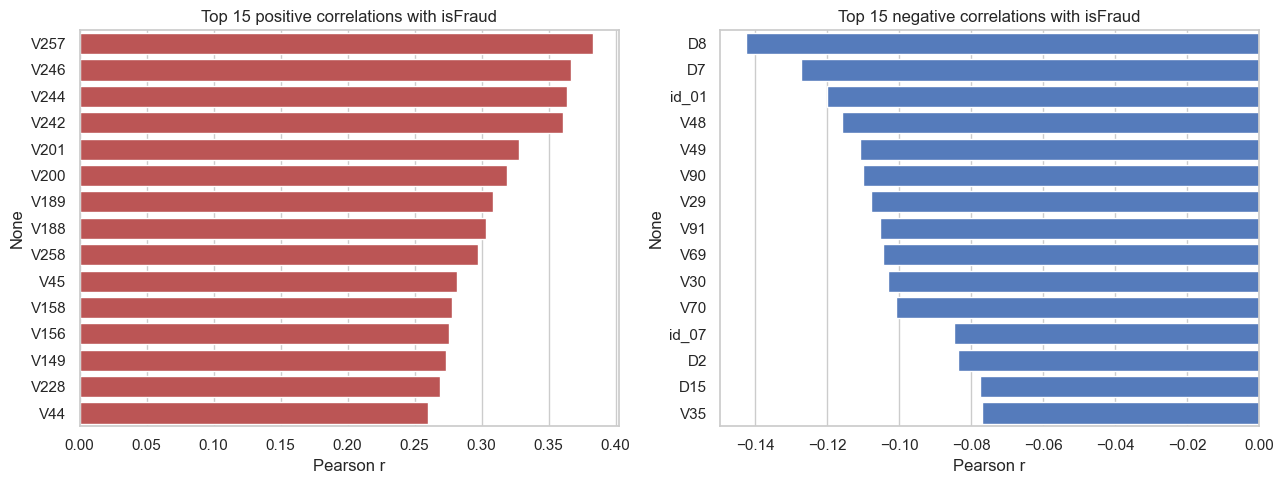

In [13]:
numeric_df = df.select_dtypes(include=[np.number])
correlations = numeric_df.corr(numeric_only=True)["isFraud"].drop("isFraud").dropna()

top_positive = correlations.sort_values(ascending=False).head(15)
top_negative = correlations.sort_values().head(15)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.barplot(x=top_positive.values, y=top_positive.index, ax=axes[0], color="#cc4444")
axes[0].set(title="Top 15 positive correlations with isFraud", xlabel="Pearson r")
sns.barplot(x=top_negative.values, y=top_negative.index, ax=axes[1], color="#4477cc")
axes[1].set(title="Top 15 negative correlations with isFraud", xlabel="Pearson r")
plt.tight_layout()
plt.show()

## 12. preprocessing + feature engineering

Things to carry forward into `src/data/preprocess.py`:

**Cleaning**
- Left-merge `transaction` + `identity` on `TransactionID`.
- Drop columns where `missing_pct > 95%` (revisit if predictive — see correlations table above).
- Cast numerics with `reduce_memory` *after* loading raw CSVs.

**Imputation**
- Numeric: median imputation, plus a `_was_missing` boolean for high-cardinality V-block columns that survive the threshold.
- Categorical: fill with the string `"missing"` so it becomes its own category.

**Engineered features (target: 3+ beyond raw columns)**
1. `log_amt = np.log1p(TransactionAmt)` — tames the skew, improves linear interpretability and SHAP plots.
2. `hour_of_day = (TransactionDT / 3600) % 24` — fraud rate varies meaningfully by hour.
3. `day_index = TransactionDT // (24 * 3600)` — useful for time-aware CV splits.
4. `email_match = (P_emaildomain == R_emaildomain).astype(int)` — purchaser/recipient identity hint.
5. `amt_per_card_mean_ratio` — `TransactionAmt` divided by the per-`card1` mean amount; flags outliers relative to a card's typical spend.

**Encoding**
- Low-cardinality categoricals (`ProductCD`, `card4`, `card6`, `DeviceType`): one-hot.
- High-cardinality (`card1`, `addr1`, `P_emaildomain`): frequency encoding or target encoding via sklearn pipeline (avoid leakage with cross-fold).

**Validation strategy**
- Time-based split using `day_index`: train on early days, validate on later days. Avoids look-ahead leakage that random K-fold would introduce on time-series-shaped data.

**Imbalance handling**
- Apply SMOTE on the **training fold only** (never on validation), inside the cross-validation loop. `imbalanced-learn`'s `Pipeline` makes this safe.